# Fine-Tuning PyTorch Models and Foundation Models

This example notebook demonstrates how to train, save, load, and fine-tune PyTorch-based models in Darts. We cover two scenarios:

1.  **Regular PyTorch Models** (e.g., TiDE, N-BEATS, DLinear):
    *   Training a model from scratch.
    *   Saving and loading the model.
    *   Fine-tuning the loaded model (updating weights on new data).

2.  **Foundation Models** (e.g., Chronos):
    *   **Zero-shot inference**: Using the model without any training (`enable_finetuning=False`).
    *   **Full fine-tuning**: Retraining all model weights (`enable_finetuning=True`).
    *   **Partial fine-tuning**: Retraining only specific layers while freezing others (`enable_finetuning={"freeze": ...}` or `{"unfreeze": ...}`).

The `enable_finetuning` parameter controls the behavior:
*   `enable_finetuning=True`: Enables global fine-tuning (all weights are trainable).
*   `enable_finetuning=False`: Disables fine-tuning (all weights are frozen).
*   `enable_finetuning={...}`: Enables partial fine-tuning via "freeze" or "unfreeze" patterns.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [3]:
import warnings

import numpy as np

from darts.datasets import AirPassengersDataset
from darts.models import Chronos2Model, TiDEModel
from darts.utils.likelihood_models.torch import QuantileRegression

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

## Data Preparation
Here we just load an example dataset with 144 samples as a fast demo. The data is split between train and validation, with the 2 last years (24 samples) for validation

In [4]:
# convert to float32 as Chronos-2 works with float32 input
data = AirPassengersDataset().load().astype(np.float32)
train_passengers, val_passengers = data.split_before(
    len(data) - 2 * 12
)  # last 2 years for validation

## 1. Regular PyTorch Model: Training, Saving, Loading and Fine-Tuning

We start with a regular PyTorch model, `TiDEModel` in this case.

First, we train a model from scratch. By default, `enable_finetuning=None`, which implies standard training for regular models (all weights are trainable).


Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Trained TiDE model'}, xlabel='Month'>

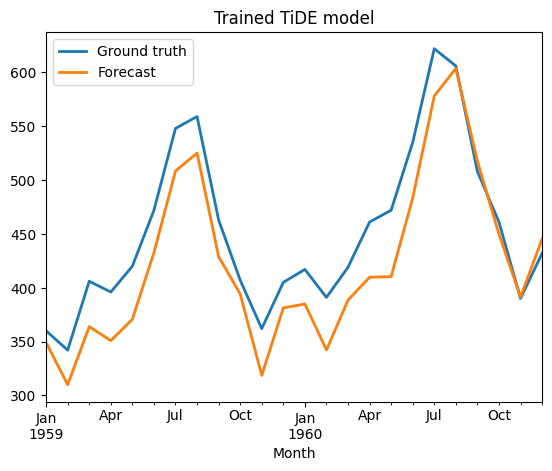

In [5]:
# Regular training (default enable_finetuning=None)
tide_model = TiDEModel(
    input_chunk_length=24,
    output_chunk_length=12,
    use_reversible_instance_norm=True,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    random_state=42,
    n_epochs=100,
    model_name="my_tide_model",
    save_checkpoints=True,  # saves the best model
    force_reset=True,
    # enable_finetuning=None,  # default: full training for regular models
)

tide_model.fit(train_passengers, verbose=True)

# Save the model manually (optional, as save_checkpoints=True already saves checkpoints)
tide_model.save("tide_model_trained.pt")

tide_prediction = tide_model.predict(
    n=len(val_passengers), series=train_passengers, random_state=42
)
val_passengers.plot(label="Ground truth")
tide_prediction.plot(label="Forecast", title="Trained TiDE model")

Predicting: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Fine-tuned TiDE model'}, xlabel='Month'>

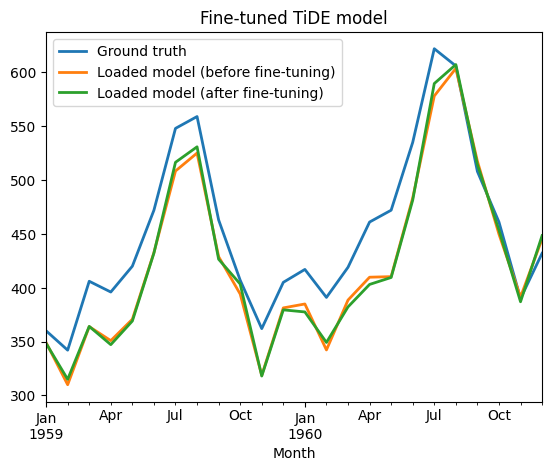

In [6]:
# Load the model (we can use the manually saved one)
loaded_model = TiDEModel.load("tide_model_trained.pt")

# Initial prediction before fine-tuning
prediction_before = loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
    random_state=42,
)
val_passengers.plot(label="Ground truth")
prediction_before.plot(
    label="Loaded model (before fine-tuning)", title="Loaded TiDE model"
)

# Fine-tune the loaded model
# Since enable_finetuning=None (default) was used, calling fit() continues training on all weights.
# We train for a few more epochs (fine-tuning)
loaded_model.fit(train_passengers, epochs=10, verbose=True)

# Predict after fine-tuning
prediction_after = loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
    random_state=42,
)
prediction_after.plot(
    label="Loaded model (after fine-tuning)", title="Fine-tuned TiDE model"
)

# 2. Foundation Model: Zero-shot, Full Fine-Tuning and Partial Fine-Tuning

Now we move to foundation models (e.g. `Chronos`). These models are pre-trained on large datasets and can often be used "zero-shot" (without training).

However, fine-tuning them on your specific data often improves performance.

The `enable_finetuning` parameter controls how the model is updated during `fit()`:
*   `enable_finetuning=False` (Default): **Zero-shot inference**. The model weights are frozen. `fit()` is used only to setup the model (scaling, etc.) but no training is performed.
*   `enable_finetuning=True`: **Full fine-tuning**. All weights are trainable.
*   `enable_finetuning={"freeze": [...]}`: **Partial fine-tuning (Freeze)**. specified layers are frozen.
*   `enable_finetuning={"unfreeze": [...]}`: **Partial fine-tuning (Unfreeze)**. All layers are frozen *except* the specified ones.

### 2.1 Zero-Shot Inference
Let's see how the model behaves on the validation data without any fine-tuning (`enable_finetuning=False`).
For that we:
- Create the model
- Call `fit()` to load the model internally (no training is done)
- Predict on the validation set


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Base model (not finetuned yet)'}, xlabel='Month'>

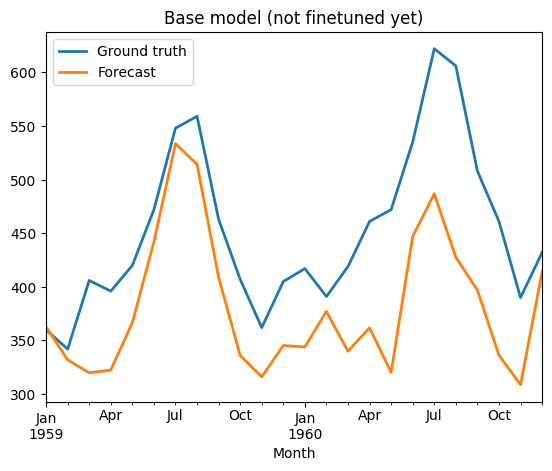

In [7]:
model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    enable_finetuning=False,
    random_state=42,
)

model.fit(train_passengers, verbose=True)

prediction = model.predict(
    n=len(val_passengers),
    series=train_passengers,
)
val_passengers.plot(label="Ground truth")
prediction.plot(label="Forecast", title="Base model (not finetuned yet)")

### 2.2 Full fine-tuning (`enable_finetuning=True`)

In this method, all the model weights are retrained. This is enabled by passing `enable_finetuning=True` to the model constructor.

When fine-tuning is enabled, Darts will treat the foundation model like a standard trainable model during `fit()`. Saving and loading follows the standard Darts API via the `save()` and `load()` methods.


In [14]:
full_finetuned_model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    enable_finetuning=True,
    n_epochs=100,
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)
full_finetuned_model.fit(train_passengers, verbose=True)
full_finetuned_model.save("full_finetuned.pt")

# Load
full_finetuned_loaded_model = Chronos2Model.load("full_finetuned.pt")

Training: |          | 0/? [00:00<?, ?it/s]

We can compare the prediction with the ground truth, as well as checking that the loaded model behaves similarly to the fine-tuned model.

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Full finetuning'}, xlabel='Month'>

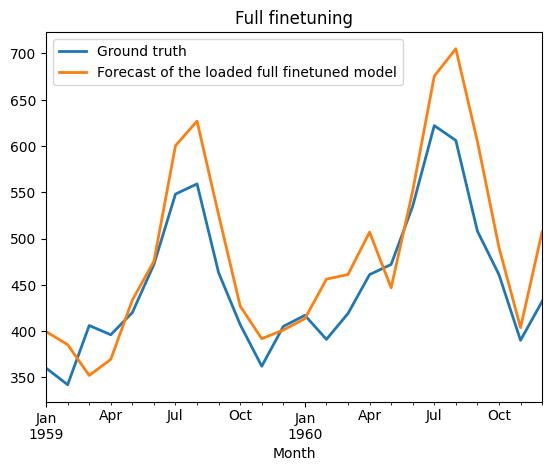

In [15]:
pred_full_finetuned_loaded = full_finetuned_loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
)
val_passengers.plot(label="Ground truth")
pred_full_finetuned_loaded.plot(
    label="Forecast of the loaded full finetuned model",
    title="Full finetuning",
)

We can also verify numericaly that the prediction of the trained model is identical to the prediction of the loaded model

### 2.3 Partial fine-tuning with layer freezing/unfreezing

Partial fine-tuning allows you to update only a subset of the model's parameters, which is useful for preserving general knowledge while adapting to specific patterns.

Darts foundation models (as well as regular PyTorch models) support this via the `enable_finetuning` parameter. You can pass a dictionary with:
- `{'freeze': ['pattern1', 'pattern2']}`: To freeze specific layers (keeping others trainable).
- `{'unfreeze': ['pattern1', 'pattern2']}`: To freeze everything *except* the matching layers.

In the example below, we show two approaches (comment/uncomment to try):
1.  **Freeze encoders**: We freeze the encoder layers, training only the rest (e.g. decoder/head).
2.  **Unfreeze head**: We freeze everything except the output head.


In [16]:
# Example 2.3: Partial fine-tuning by UNFREEZING layers
# Here we want to fine-tune ONLY specific layers (e.g. `output_patch_embedding`), keeping the backbone frozen.
# Note: Layer names depend on the model architecture.

partial_finetuned_model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    # OPTION 1: Unfreeze specific layers (freeze everything else)
    # This trains ONLY the layers matching "output_patch_embedding"
    enable_finetuning={"unfreeze": ["output_patch_embedding.*"]},
    # OPTION 2: Freeze specific layers (train everything else)
    # enable_finetuning={"freeze": ["*encoder*"]},
    n_epochs=100,
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)

partial_finetuned_model.fit(train_passengers, verbose=True)
partial_finetuned_model.save("partial_finetuned.pt")

# Load - no callback needed, structure unchanged
partial_finetuned_loaded_model = Chronos2Model.load("partial_finetuned.pt")

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Partial finetuning'}, xlabel='Month'>

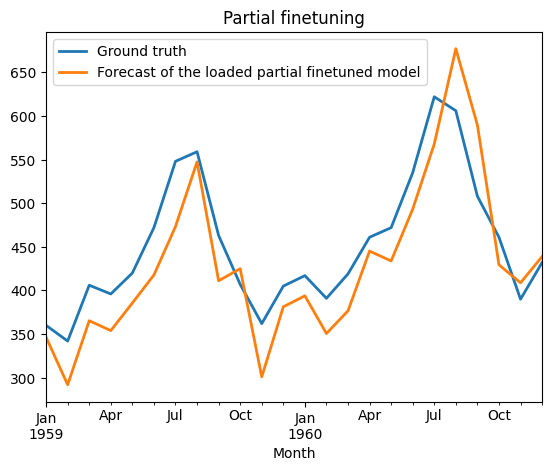

In [17]:
pred_partial_finetuned_loaded = partial_finetuned_loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
    random_state=42,
)
val_passengers.plot(label="Ground truth")
pred_partial_finetuned_loaded.plot(
    label="Forecast of the loaded partial finetuned model",
    title="Partial finetuning",
)

Again, we verify that the prediction of the fine-tuned model is the same as the loaded model to make sure that saving/load works correctly

# 3. Performance Evaluation

Finally, let's compare the performance of the three models (Base, Full Fine-tuning, and Partial Fine-tuning) on the validation set using standard metrics like **MAPE** (Mean Absolute Percentage Error) and **MAE** (Mean Absolute Error).

In [18]:
import pandas as pd

from darts.metrics import mae, mape

results = []
all_predictions = {
    "Trained TiDE Model": tide_prediction,
    "Loaded TiDE Model (Fine-Tuned)": prediction_after,
    "Chronos Zero-Shot (Base)": prediction,
    "Chronos Full Fine-tuning": pred_full_finetuned_loaded,
    "Chronos Partial Fine-tuning": pred_partial_finetuned_loaded,
}

for name, pred in all_predictions.items():
    results.append({
        "Model": name,
        "MAPE (%)": mape(val_passengers, pred),
        "MAE": mae(val_passengers, pred),
    })

df_results = pd.DataFrame(results)
df_results

,Model,MAPE (%),MAE
0,Trained TiDE Model,7.183538,31.838135
1,Loaded TiDE Model (Fine-Tuned),7.088335,31.208529
2,Chronos Zero-Shot (Base),15.206929,70.817078
3,Chronos Full Fine-tuning,8.920057,40.941208
4,Chronos Partial Fine-tuning,8.660080,39.234516


### Observations

While the results on this small "toy" dataset (Air Passengers) may vary depending on the random seed and hyperparameters, they demonstrate the flexibility of the fine-tuning API.

In real-world scenarios with larger datasets:
- **Regular Models**: Fine-tuning allows updating a pre-trained model on new data, potentially saving training time compared to retraining from scratch.
- **Foundation Models**:
    - **Zero-Shot**: Quick and easy, no training required.
    - **Full Fine-tuning**: Offers the most flexibility but is computationally expensive and prone to "catastrophic forgetting".
    - **Partial Fine-tuning**: Provides a good middle ground by updating only the most relevant layers (like the output head).

### Summary
In this notebook, we have seen:
1.  How to train, save, load, and naturally fine-tune **regular PyTorch models**.
2.  How to apply **zero-shot inference** with foundation models.
3.  How to perform **full fine-tuning** on foundation models.
4.  How to use **layer freezing/unfreezing** for **partial fine-tuning**.
